# Feature Scaling - Normalization 📊

## What is Normalization?

**Normalization** (also called Min-Max scaling) is a data preprocessing technique that transforms features to a common scale, typically between 0 and 1, without distorting differences in the ranges of values.

The mathematical formula for Min-Max normalization is:

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Where:
- $X_{norm}$ is the normalized value
- $X_{min}$ is the minimum value in the feature
- $X_{max}$ is the maximum value in the feature

## Why is Normalization Important? 🎯

1. **Equal Contribution**: Prevents features with larger magnitudes from dominating those with smaller magnitudes
2. **Algorithm Performance**: Many ML algorithms perform better with normalized data
3. **Faster Convergence**: Gradient descent converges faster when features are on similar scales
4. **Improved Accuracy**: Can lead to better model accuracy and stability
5. **Distance-based Algorithms**: Essential for algorithms that compute distances between data points

## What is it Used For? 💡

Normalization is commonly used in:
- **Machine Learning Preprocessing**
- **Deep Learning** (especially for neural networks with activation functions like sigmoid/tanh)
- **Image Processing** (normalizing pixel values from 0-255 to 0-1)
- **Pattern Recognition**
- **Clustering Algorithms**
- **Principal Component Analysis (PCA)**

## When to Use Normalization? ✅

Use normalization when:
- **You have no knowledge about the data distribution**
- **The algorithm assumes normally distributed data** (though standardization is better for this)
- **You're using neural networks with sigmoid/tanh activation functions**
- **You need bounded values** (e.g., between 0 and 1)
- **The data doesn't follow Gaussian distribution**
- **Working with distance-based algorithms** (KNN, K-means, SVM)

## When NOT to Use Normalization? ❌

Avoid normalization when:
- **Your data already has comparable scales**
- **You have outliers** (normalization is sensitive to outliers)
- **The algorithm is scale-invariant** (like tree-based models: Decision Trees, Random Forest, XGBoost)
- **You want to preserve the original distribution shape**
- **The data has a Gaussian distribution** (standardization is better)

## On What Type of Data Should Normalization Be Applied? 📋

- **Numerical continuous data** with varying ranges
- **Pixel intensities** in images (0-255 to 0-1)
- **Feature vectors** in NLP (word counts, TF-IDF scores)
- **Sensor data** with different measurement units
- **Financial data** with different scales (prices, volumes, ratios)

## Types of Normalization 🔄

### 1. **Min-Max Normalization** (Most Common)
$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$
- Scales data to [0, 1]
- Sensitive to outliers

### 2. **Mean Normalization**
$$X_{norm} = \frac{X - \mu}{X_{max} - X_{min}}$$
- Centers data around 0
- Range: [-1, 1] approximately

### 3. **Max Absolute Scaling**
$$X_{norm} = \frac{X}{|X_{max}|}$$
- Scales to [-1, 1]
- Preserves sparsity

### 4. **Robust Scaling** (for outliers)
$$X_{norm} = \frac{X - median}{IQR}$$
- Uses median and IQR instead of mean and variance
- Handles outliers better




### Example 1: Simple Min-Max Normalization

Original Data:
   Age  Salary  Experience
0   25   30000           1
1   30   45000           3
2   35   60000           5
3   40   75000           7
4   45   90000          10
5   50  105000          15
6  100  200000          30


Normalized Data (0-1 range):
        Age    Salary  Experience
0  0.000000  0.000000    0.000000
1  0.066667  0.088235    0.068966
2  0.133333  0.176471    0.137931
3  0.200000  0.264706    0.206897
4  0.266667  0.352941    0.310345
5  0.333333  0.441176    0.482759
6  1.000000  1.000000    1.000000


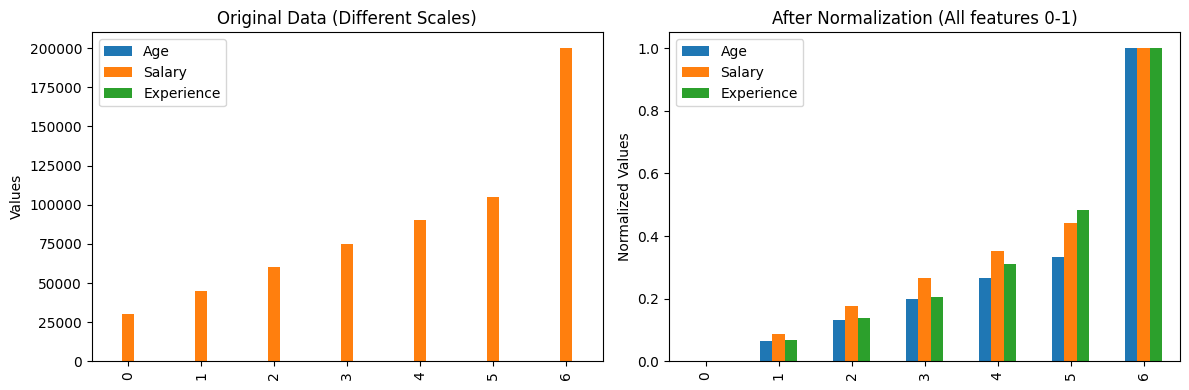

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Sample data with different scales
data = {
    'Age': [25, 30, 35, 40, 45, 50, 100],  # Age in years
    'Salary': [30000, 45000, 60000, 75000, 90000, 105000, 200000],  # Salary in $
    'Experience': [1, 3, 5, 7, 10, 15, 30]  # Years of experience
}

df = pd.DataFrame(data)
print("Original Data:")
print(df)
print("\n" + "="*50 + "\n")

# Apply Min-Max Normalization
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

print("Normalized Data (0-1 range):")
print(df_normalized)

# Visualize the effect
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Original data
df.plot(kind='bar', ax=ax1)
ax1.set_title('Original Data (Different Scales)')
ax1.set_ylabel('Values')

# Normalized data
df_normalized.plot(kind='bar', ax=ax2)
ax2.set_title('After Normalization (All features 0-1)')
ax2.set_ylabel('Normalized Values')

plt.tight_layout()
plt.show()

### Example 2: Impact on Machine Learning

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Create sample classification data with different scales
np.random.seed(42)
n_samples = 100

# Feature 1: Age (range 20-80)
age = np.random.uniform(20, 80, n_samples)

# Feature 2: Income (range 20000-200000)
income = np.random.uniform(20000, 200000, n_samples)

# Feature 3: Score (range 0-100)
score = np.random.uniform(0, 100, n_samples)

# Create labels (simple logic based on features)
labels = ((age > 40) & (income > 100000)).astype(int)

X = np.column_stack([age, income, score])
y = labels

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train KNN without normalization
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)

# Train KNN with normalization
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

print("KNN Classification Results:")
print(f"Without Normalization: {acc_unscaled:.3f}")
print(f"With Normalization: {acc_scaled:.3f}")
print(f"Improvement: {((acc_scaled - acc_unscaled) * 100):.1f}%")

KNN Classification Results:
Without Normalization: 0.600
With Normalization: 0.933
Improvement: 33.3%


### Example 3: Different Normalization Methods Comparison

In [3]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MaxAbsScaler

# Sample data with outliers
data_with_outliers = np.array([
    [100, 0.001],
    [200, 0.002],
    [150, 0.0015],
    [1000, 0.1],  # outlier in first feature
    [180, 0.0018],
    [220, 0.0022]
])

# Apply different scaling methods
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
maxabs_scaler = MaxAbsScaler()

data_minmax = minmax_scaler.fit_transform(data_with_outliers)
data_robust = robust_scaler.fit_transform(data_with_outliers)
data_maxabs = maxabs_scaler.fit_transform(data_with_outliers)

print("Original Data:")
print(data_with_outliers)
print("\nMin-Max Normalization (affected by outlier):")
print(data_minmax)
print("\nRobust Scaling (handles outlier better):")
print(data_robust)
print("\nMaxAbs Scaling:")
print(data_maxabs)

Original Data:
[[1.0e+02 1.0e-03]
 [2.0e+02 2.0e-03]
 [1.5e+02 1.5e-03]
 [1.0e+03 1.0e-01]
 [1.8e+02 1.8e-03]
 [2.2e+02 2.2e-03]]

Min-Max Normalization (affected by outlier):
[[0.         0.        ]
 [0.11111111 0.01010101]
 [0.05555556 0.00505051]
 [1.         1.        ]
 [0.08888889 0.00808081]
 [0.13333333 0.01212121]]

Robust Scaling (handles outlier better):
[[ -1.56521739  -1.56521739]
 [  0.17391304   0.17391304]
 [ -0.69565217  -0.69565217]
 [ 14.08695652 170.60869565]
 [ -0.17391304  -0.17391304]
 [  0.52173913   0.52173913]]

MaxAbs Scaling:
[[0.1   0.01 ]
 [0.2   0.02 ]
 [0.15  0.015]
 [1.    1.   ]
 [0.18  0.018]
 [0.22  0.022]]



### Example 4: Real-world Application - Student Performance

In [4]:
# Student dataset with different metrics
students_data = {
    'Student': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Exam_Score': [85, 92, 78, 95, 88],  # 0-100 scale
    'Study_Hours': [10, 15, 8, 20, 12],  # hours per week
    'Previous_Grades': [3.5, 3.8, 3.2, 4.0, 3.6],  # GPA scale (0-4)
    'Attendance': [90, 95, 85, 98, 92]  # percentage
}

df_students = pd.DataFrame(students_data)
df_students.set_index('Student', inplace=True)

print("Student Performance Data (Original):")
print(df_students)
print("\n" + "="*50)

# Normalize for fair comparison
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_students),
    columns=df_students.columns,
    index=df_students.index
)

print("\nNormalized Student Data:")
print(df_normalized)

# Calculate overall performance score (average of normalized features)
df_normalized['Overall_Score'] = df_normalized.mean(axis=1)
df_normalized_sorted = df_normalized.sort_values('Overall_Score', ascending=False)

print("\nStudent Rankings (based on normalized scores):")
print(df_normalized_sorted[['Overall_Score']])

Student Performance Data (Original):
         Exam_Score  Study_Hours  Previous_Grades  Attendance
Student                                                      
Alice            85           10              3.5          90
Bob              92           15              3.8          95
Charlie          78            8              3.2          85
David            95           20              4.0          98
Eve              88           12              3.6          92


Normalized Student Data:
         Exam_Score  Study_Hours  Previous_Grades  Attendance
Student                                                      
Alice      0.411765     0.166667            0.375    0.384615
Bob        0.823529     0.583333            0.750    0.769231
Charlie    0.000000     0.000000            0.000    0.000000
David      1.000000     1.000000            1.000    1.000000
Eve        0.588235     0.333333            0.500    0.538462

Student Rankings (based on normalized scores):
         Overall_Sco

### Impact of Outliers on Normalization 

#### The Problem with Outliers in Normalization
When outliers are present in your data, Min-Max normalization can be significantly affected because it uses the minimum and maximum values to scale the data. Let me explain the impact with examples:

### Visual Impact of Outliers

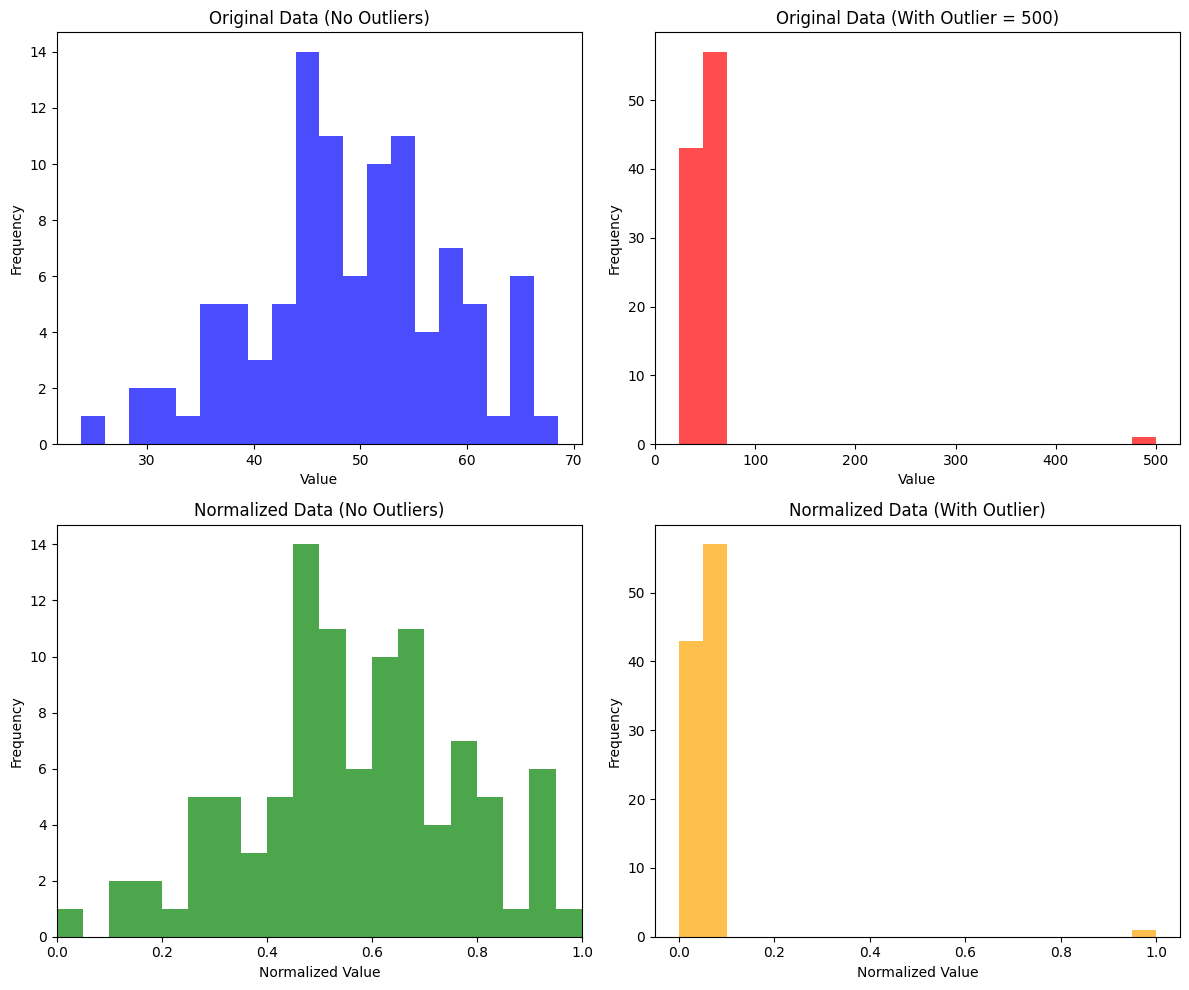

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Create data with and without outliers
np.random.seed(42)
normal_data = np.random.normal(50, 10, 100)  # Normal distribution
data_with_outlier = np.append(normal_data, [500])  # Add extreme outlier

# Reshape for scaler
normal_data = normal_data.reshape(-1, 1)
data_with_outlier = data_with_outlier.reshape(-1, 1)

# Apply MinMax scaling
scaler_normal = MinMaxScaler()
scaler_outlier = MinMaxScaler()

normal_scaled = scaler_normal.fit_transform(normal_data)
outlier_scaled = scaler_outlier.fit_transform(data_with_outlier)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original data distribution
axes[0, 0].hist(normal_data, bins=20, alpha=0.7, color='blue')
axes[0, 0].set_title('Original Data (No Outliers)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(data_with_outlier, bins=20, alpha=0.7, color='red')
axes[0, 1].set_title('Original Data (With Outlier = 500)')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')

# Scaled data distribution
axes[1, 0].hist(normal_scaled, bins=20, alpha=0.7, color='green')
axes[1, 0].set_title('Normalized Data (No Outliers)')
axes[1, 0].set_xlabel('Normalized Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xlim(0, 1)

axes[1, 1].hist(outlier_scaled, bins=20, alpha=0.7, color='orange')
axes[1, 1].set_title('Normalized Data (With Outlier)')
axes[1, 1].set_xlabel('Normalized Value')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Key Impacts of Outliers on Normalization
#### 1. Compression of Normal Data
When an outlier is present, the normal data points get squeezed into a very small range:

In [6]:
# Demonstrate compression effect
data = np.array([10, 12, 11, 13, 12, 500])  # Normal range 10-13, outlier at 500

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.reshape(-1, 1)).flatten()

print("Original Data:", data)
print("Scaled Data:", scaled_data)
print("\n" + "="*50)

# Calculate statistics
print(f"Original Range: {data.min():.2f} to {data.max():.2f}")
print(f"Normal Data Range (without outlier): 10 to 13")
print(f"Scaled Range: {scaled_data.min():.4f} to {scaled_data.max():.4f}")
print(f"Normal data points scaled values: {scaled_data[:-1]}")

Original Data: [ 10  12  11  13  12 500]
Scaled Data: [0.         0.00408163 0.00204082 0.00612245 0.00408163 1.        ]

Original Range: 10.00 to 500.00
Normal Data Range (without outlier): 10 to 13
Scaled Range: 0.0000 to 1.0000
Normal data points scaled values: [0.         0.00408163 0.00204082 0.00612245 0.00408163]


Output shows: Normal points (10-13) get compressed to ~0-0.006 range, while outlier takes almost the entire 0-1 range!

#### 2. Loss of Distinguishability

In [7]:
# Show how normal points become hard to distinguish
import pandas as pd

# Create dataset with multiple features
data_multi = pd.DataFrame({
    'Feature1': [1, 2, 3, 4, 5, 100],  # outlier in Feature1
    'Feature2': [100, 200, 300, 400, 500, 600],  # no relative outlier
    'Feature3': [10, 20, 30, 40, 50, 60]  # no relative outlier
})

print("Original Data:")
print(data_multi)
print("\n" + "="*50)

# Apply MinMax scaling
scaler = MinMaxScaler()
scaled_multi = pd.DataFrame(
    scaler.fit_transform(data_multi),
    columns=data_multi.columns
)

print("\nNormalized Data (with outlier effect):")
print(scaled_multi)

# Calculate variance before and after
print("\nVariance Analysis:")
print(f"Original Feature1 variance: {data_multi['Feature1'].var():.2f}")
print(f"Scaled Feature1 variance: {scaled_multi['Feature1'].var():.4f}")
print(f"Original Feature2 variance: {data_multi['Feature2'].var():.2f}")
print(f"Scaled Feature2 variance: {scaled_multi['Feature2'].var():.4f}")

Original Data:
   Feature1  Feature2  Feature3
0         1       100        10
1         2       200        20
2         3       300        30
3         4       400        40
4         5       500        50
5       100       600        60


Normalized Data (with outlier effect):
   Feature1  Feature2  Feature3
0  0.000000       0.0       0.0
1  0.010101       0.2       0.2
2  0.020202       0.4       0.4
3  0.030303       0.6       0.6
4  0.040404       0.8       0.8
5  1.000000       1.0       1.0

Variance Analysis:
Original Feature1 variance: 1570.17
Scaled Feature1 variance: 0.1602
Original Feature2 variance: 35000.00
Scaled Feature2 variance: 0.1400


#### 3. Effect on Machine Learning Models

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create dataset with outlier influence
np.random.seed(42)
n_samples = 200

# Generate normal data
X_normal = np.random.randn(n_samples, 2) * 2 + 5
y_normal = np.random.randint(0, 2, n_samples)

# Add outlier
X_outlier = np.array([[100, 100]])  # Extreme outlier
y_outlier = np.array([1])

X_with_outlier = np.vstack([X_normal, X_outlier])
y_with_outlier = np.append(y_normal, y_outlier)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_with_outlier, y_with_outlier, test_size=0.3, random_state=42
)

# Train without normalization
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
y_pred_raw = knn_raw.predict(X_test)

# Train with MinMax normalization (affected by outlier)
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

knn_minmax = KNeighborsClassifier(n_neighbors=5)
knn_minmax.fit(X_train_minmax, y_train)
y_pred_minmax = knn_minmax.predict(X_test_minmax)

# Train with Robust scaling (handles outliers better)
scaler_robust = RobustScaler()
X_train_robust = scaler_robust.fit_transform(X_train)
X_test_robust = scaler_robust.transform(X_test)

knn_robust = KNeighborsClassifier(n_neighbors=5)
knn_robust.fit(X_train_robust, y_train)
y_pred_robust = knn_robust.predict(X_test_robust)

print("Model Performance Comparison:")
print(f"Raw Data (no scaling): {accuracy_score(y_test, y_pred_raw):.3f}")
print(f"MinMax Scaling (affected by outlier): {accuracy_score(y_test, y_pred_minmax):.3f}")
print(f"Robust Scaling (handles outliers): {accuracy_score(y_test, y_pred_robust):.3f}")

Model Performance Comparison:
Raw Data (no scaling): 0.492
MinMax Scaling (affected by outlier): 0.508
Robust Scaling (handles outliers): 0.525


## Why Outliers Cause Problems in Min-Max Normalization?

### Mathematical Explanation

For Min-Max normalization:

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

When an outlier exists:

- **$X_{max}$ becomes extremely large**
- **Denominator $(X_{max} - X_{min})$ becomes very large**
- **All normal points get divided by this large denominator**
- **Result: Normal points cluster near 0, outlier near 1**

In [9]:
# Mathematical demonstration
X = np.array([10, 12, 11, 13, 12, 500])
X_min = X.min()
X_max = X.max()

print(f"X_min: {X_min}")
print(f"X_max: {X_max}")
print(f"Range (X_max - X_min): {X_max - X_min}")
print("\nNormalization calculations:")
for i, val in enumerate(X):
    norm_val = (val - X_min) / (X_max - X_min)
    print(f"Point {val}: ({val} - {X_min}) / ({X_max} - {X_min}) = {norm_val:.4f}")

X_min: 10
X_max: 500
Range (X_max - X_min): 490

Normalization calculations:
Point 10: (10 - 10) / (500 - 10) = 0.0000
Point 12: (12 - 10) / (500 - 10) = 0.0041
Point 11: (11 - 10) / (500 - 10) = 0.0020
Point 13: (13 - 10) / (500 - 10) = 0.0061
Point 12: (12 - 10) / (500 - 10) = 0.0041
Point 500: (500 - 10) / (500 - 10) = 1.0000


## Solutions for Handling Outliers in Normalization
### 1. Use Robust Scaling

In [10]:
from sklearn.preprocessing import RobustScaler

# Compare MinMax vs Robust scaling
data_with_outliers = np.array([1, 2, 3, 4, 5, 100, 200]).reshape(-1, 1)

minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

minmax_scaled = minmax_scaler.fit_transform(data_with_outliers)
robust_scaled = robust_scaler.fit_transform(data_with_outliers)

comparison = pd.DataFrame({
    'Original': data_with_outliers.flatten(),
    'MinMax Scaled': minmax_scaled.flatten(),
    'Robust Scaled': robust_scaled.flatten()
})

print("Comparison of Scaling Methods:")
print(comparison)
print("\n" + "="*50)
print("MinMax - Most points compressed near 0")
print("Robust - Better spread of normal points")

Comparison of Scaling Methods:
   Original  MinMax Scaled  Robust Scaled
0         1       0.000000          -0.06
1         2       0.005025          -0.04
2         3       0.010050          -0.02
3         4       0.015075           0.00
4         5       0.020101           0.02
5       100       0.497487           1.92
6       200       1.000000           3.92

MinMax - Most points compressed near 0
Robust - Better spread of normal points


### 2. Remove or Cap Outliers First

In [11]:
from scipy import stats

def handle_outliers(data, method='winsorize', threshold=3):
    """
    Handle outliers before normalization
    """
    if method == 'zscore':
        # Remove outliers based on Z-score
        z_scores = np.abs(stats.zscore(data))
        return data[(z_scores < threshold).all(axis=1)]
    
    elif method == 'winsorize':
        # Cap outliers at percentiles
        p1 = np.percentile(data, 5, axis=0)
        p99 = np.percentile(data, 95, axis=0)
        return np.clip(data, p1, p99)
    
    elif method == 'iqr':
        # Remove outliers based on IQR
        Q1 = np.percentile(data, 25, axis=0)
        Q3 = np.percentile(data, 75, axis=0)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return data[((data >= lower_bound) & (data <= upper_bound)).all(axis=1)]

# Example
data_with_outliers = np.array([[1, 10], [2, 20], [3, 30], 
                                [4, 40], [100, 500], [200, 1000]])

print("Original data shape:", data_with_outliers.shape)
cleaned_data = handle_outliers(data_with_outliers, method='iqr')
print("Cleaned data shape:", cleaned_data.shape)

Original data shape: (6, 2)
Cleaned data shape: (5, 2)


### 3. Use Quantile Transformation

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, RobustScaler, QuantileTransformer
import matplotlib.pyplot as plt

# Original data with outliers
data_with_outliers = np.array([1, 2, 3, 4, 5, 100, 200]).reshape(-1, 1)

# Apply different scaling methods
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()
quantile_scaler = QuantileTransformer(output_distribution='uniform')

minmax_scaled = minmax_scaler.fit_transform(data_with_outliers)
robust_scaled = robust_scaler.fit_transform(data_with_outliers)
quantile_scaled = quantile_scaler.fit_transform(data_with_outliers)

# Create comparison DataFrame correctly
comparison = pd.DataFrame({
    'Original': data_with_outliers.flatten(),
    'MinMax Scaled': minmax_scaled.flatten(),
    'Robust Scaled': robust_scaled.flatten(),
    'Quantile Scaled': quantile_scaled.flatten()
})

print("Comparison of Scaling Methods:")
print(comparison)
print("\n" + "="*70)
print("Observations:")
print("- MinMax: Most points compressed near 0 due to outlier")
print("- Robust: Better spread of normal points (uses median/IQR)")
print("- Quantile: Forces uniform distribution, handles outliers well")

Comparison of Scaling Methods:
   Original  MinMax Scaled  Robust Scaled  Quantile Scaled
0         1       0.000000          -0.06         0.000000
1         2       0.005025          -0.04         0.166667
2         3       0.010050          -0.02         0.333333
3         4       0.015075           0.00         0.500000
4         5       0.020101           0.02         0.666667
5       100       0.497487           1.92         0.833333
6       200       1.000000           3.92         1.000000

Observations:
- MinMax: Most points compressed near 0 due to outlier
- Robust: Better spread of normal points (uses median/IQR)
- Quantile: Forces uniform distribution, handles outliers well


### Visual Comparison of Different Approaches

Dataset Statistics:
Total points: 103
Normal points: 100
Outliers: 3


First 10 rows of scaled data:
    Original    MinMax    Robust  Quantile  Standard
0  54.967142  0.046088  0.512652  0.735294 -0.106708
1  48.617357  0.036698 -0.059722  0.480392 -0.174168
2  56.476885  0.048321  0.648741  0.774510 -0.090668
3  65.230299  0.061266  1.437780  0.931373  0.002328
4  47.658466  0.035280 -0.146157  0.431373 -0.184355
5  47.658630  0.035280 -0.146142  0.441176 -0.184353
6  65.792128  0.062097  1.488424  0.960784  0.008297
7  57.674347  0.050092  0.756681  0.794118 -0.077947
8  45.305256  0.031799 -0.358277  0.313725 -0.209355
9  55.425600  0.046766  0.553978  0.754902 -0.101837


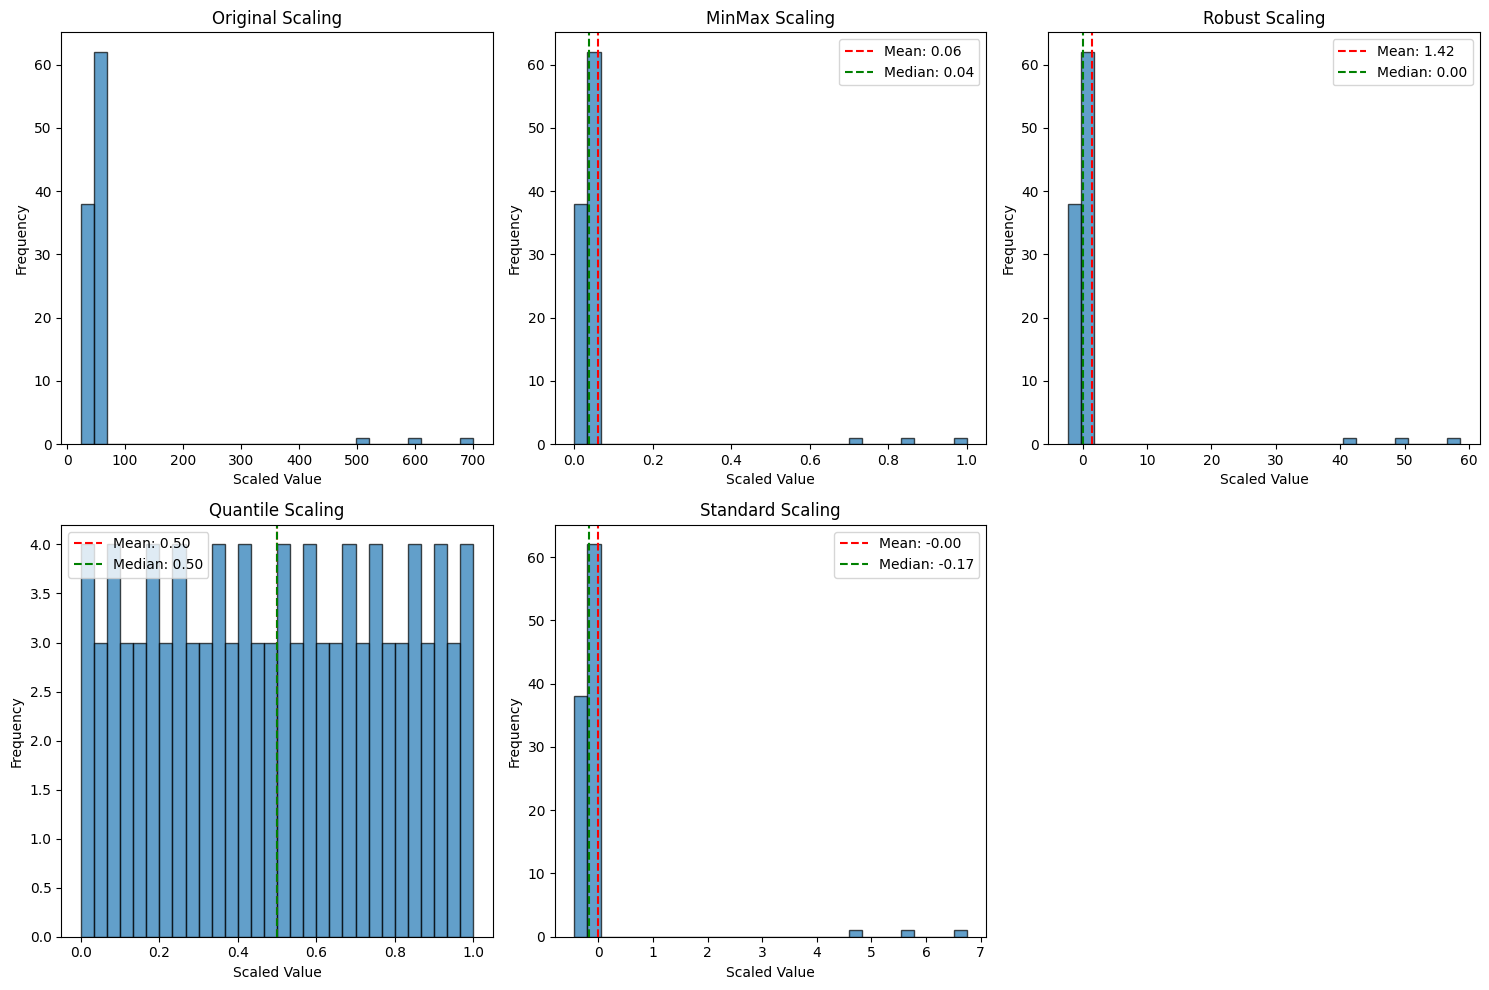


Statistical Summary:

Original Scaling:
  Mean: 65.0112
  Std: 94.1267
  Min: 23.8025
  Max: 700.0000
  Range: 676.1975

MinMax Scaling:
  Mean: 0.0609
  Std: 0.1392
  Min: 0.0000
  Max: 1.0000
  Range: 1.0000

Robust Scaling:
  Mean: 1.4180
  Std: 8.4846
  Min: -2.2965
  Max: 58.6564
  Range: 60.9529

Quantile Scaling:
  Mean: 0.5000
  Std: 0.2915
  Min: 0.0000
  Max: 1.0000
  Range: 1.0000

Standard Scaling:
  Mean: -0.0000
  Std: 1.0000
  Min: -0.4378
  Max: 6.7461
  Range: 7.1839


In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, RobustScaler, QuantileTransformer, StandardScaler
import matplotlib.pyplot as plt

# Generate data with outliers
np.random.seed(42)
normal_data = np.random.normal(50, 10, 100)  # 100 normal points
outliers = np.array([500, 600, 700])  # 3 outliers
data_with_outliers = np.concatenate([normal_data, outliers]).reshape(-1, 1)

# Apply different scaling methods
scalers = {
    'Original': data_with_outliers.flatten(),
    'MinMax': MinMaxScaler().fit_transform(data_with_outliers).flatten(),
    'Robust': RobustScaler().fit_transform(data_with_outliers).flatten(),
    'Quantile': QuantileTransformer(output_distribution='uniform').fit_transform(data_with_outliers).flatten(),
    'Standard': StandardScaler().fit_transform(data_with_outliers).flatten()  # for comparison
}

# Create DataFrame for comparison
results_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in scalers.items()]))
print("Dataset Statistics:")
print(f"Total points: {len(data_with_outliers)}")
print(f"Normal points: {len(normal_data)}")
print(f"Outliers: {len(outliers)}")
print("\n" + "="*70)
print("\nFirst 10 rows of scaled data:")
print(results_df.head(10))

# Visualize the effect
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, data) in enumerate(scalers.items()):
    axes[idx].hist(data, bins=30, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{name} Scaling')
    axes[idx].set_xlabel('Scaled Value')
    axes[idx].set_ylabel('Frequency')
    
    # Add vertical lines for mean/median if applicable
    if name != 'Original':
        axes[idx].axvline(x=np.mean(data), color='red', linestyle='--', label=f'Mean: {np.mean(data):.2f}')
        axes[idx].axvline(x=np.median(data), color='green', linestyle='--', label=f'Median: {np.median(data):.2f}')
        axes[idx].legend()

# Hide empty subplot if any
if len(scalers) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*70)
print("Statistical Summary:")
print("="*70)
for name, data in scalers.items():
    print(f"\n{name} Scaling:")
    print(f"  Mean: {np.mean(data):.4f}")
    print(f"  Std: {np.std(data):.4f}")
    print(f"  Min: {np.min(data):.4f}")
    print(f"  Max: {np.max(data):.4f}")
    print(f"  Range: {np.max(data) - np.min(data):.4f}")

## Summary: Impact of Outliers on Normalization 📝

| Aspect | Impact | Consequence |
|--------|--------|-------------|
| **Scale Range** | Denominator becomes huge | Normal points compressed |
| **Data Distribution** | Skewed transformation | Loss of information in normal range |
| **Model Performance** | Poor for distance-based models | Reduced accuracy |
| **Feature Importance** | Outlier feature dominates | Other features become irrelevant |
| **Interpretability** | Hard to interpret normalized values | Meaningless scales |

## Best Practices When Outliers Present ✅

1. **Always check for outliers** before applying Min-Max normalization
2. **Use RobustScaler** when outliers are present but you want to keep them
3. **Consider outlier removal** if outliers are errors or irrelevant
4. **Try QuantileTransformer** for non-linear transformations
5. **Document your approach** and justify your scaling choice

## Quick Decision Guide
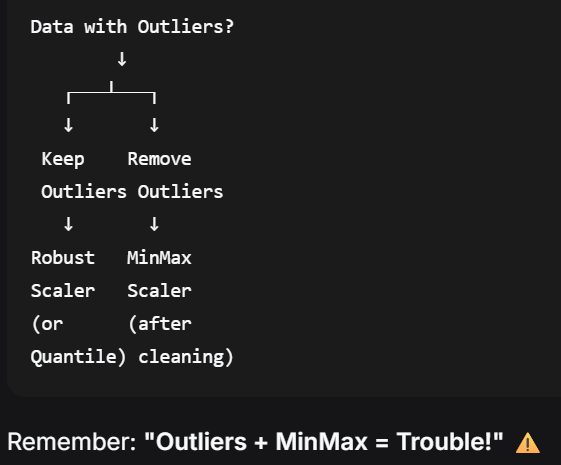